In [ ]:
# ============================================================================
# STEP 0: MOUNT GOOGLE DRIVE AND LOAD DATA
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import RobustScaler


print("=" * 80)
print("MARKET PRICE PREDICTION MODEL - OROMIA MARKETS")
print("=" * 80)

# ============================================================================
# STEP 1: LOAD YOUR DATASET
# ============================================================================

print("\n📂 STEP 1: Loading dataset from Google Drive...")

# Update this path to your actual file location
file_path = '/content/drive/MyDrive/oromia_market_price_prediction_data.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Successfully loaded {len(df):,} records")
    print(f"📊 Columns: {len(df.columns)}")
except Exception as e:
    print(f"❌ Error loading file: {e}")
    # Try alternative method
    from google.colab import files
    print("\n📤 Please upload your CSV file:")
    uploaded = files.upload()
    for filename in uploaded.keys():
        df = pd.read_csv(filename)
        print(f"✅ Loaded {filename} with {len(df):,} records")
        break

print(f"\n📋 First 5 rows:")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MARKET PRICE PREDICTION MODEL - OROMIA MARKETS

📂 STEP 1: Loading dataset from Google Drive...
✅ Successfully loaded 49,910 records
📊 Columns: 33

📋 First 5 rows:
       date commodity_item_type         market_location        zone  \
0  4/1/2021             Cabbage              Shashemene   West Arsi   
1  4/2/2021        Teff (White)                    Mojo  East Shewa   
2  4/3/2021            Tomatoes                    Mojo  East Shewa   
3  4/4/2021      Maize (Yellow)                    Meki  East Shewa   
4  4/5/2021    Potatoes (Irish)  Bishoftu (Debre Zeyit)  East Shewa   

  unit_standardization  current_price_etb  price_lag_t1  price_lag_t2  \
0                   kg               7.62         35.09         22.68   
1                   kg              48.18          6.85         31.52   
2                   kg              21.75         48.18       

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


Feature Engineering

Normalize the date


In [ ]:
# Ensure datetime
df['date'] = pd.to_datetime(df['date'])

# Keep order
df = df.sort_values('date').reset_index(drop=True)

# Year range
start_year = 2000
end_year = 2025
years = np.linspace(start_year, end_year, len(df)).astype(int)

def safe_replace_year(date_value, new_year):
    try:
        return date_value.replace(year=int(new_year))
    except ValueError:
        # handles Feb 29 -> Feb 28 in non-leap years
        return date_value.replace(year=int(new_year), day=28)

df['date'] = [safe_replace_year(d, y) for d, y in zip(df['date'], years)]

print("New min:", df['date'].min())
print("New max:", df['date'].max())

New min: 2000-01-01 00:00:00
New max: 2025-09-26 00:00:00


In [ ]:
print("\n📅 DATE COLUMN ANALYSIS")
print("=" * 50)

# Check if column exists
if 'date' in df.columns:
    print(f"Data type: {df['date'].dtype}")

    # Convert to datetime safely
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    print(f"\nAfter conversion type: {df['date'].dtype}")
    print(f"Min date: {df['date'].min()}")
    print(f"Max date: {df['date'].max()}")

    # Check invalid dates
    invalid_dates = df['date'].isnull().sum()
    print(f"Invalid/missing dates: {invalid_dates}")

    # Check uniqueness
    print(f"Unique dates: {df['date'].nunique()}")

    # Check distribution
    print(f"\nSample dates:")
    print(df['date'].head())

else:
    print("❌ 'date' column not found in dataset")


📅 DATE COLUMN ANALYSIS
Data type: datetime64[ns]

After conversion type: datetime64[ns]
Min date: 2000-01-01 00:00:00
Max date: 2025-11-23 00:00:00
Invalid/missing dates: 0
Unique dates: 9133

Sample dates:
0   2000-04-01
1   2000-04-02
2   2000-04-03
3   2000-04-04
4   2000-04-05
Name: date, dtype: datetime64[ns]


In [ ]:
dup_check = df.duplicated(subset=['date', 'commodity_item_type', 'market_location', 'zone'])
print("Exact duplicate entity-date rows:", dup_check.sum())

Exact duplicate entity-date rows: 548



🔧 STEP 1: Initial setup...
✅ Date range: 2000-01-01 00:00:00 to 2025-11-23 00:00:00
✅ Initial dataset size: 49,362
✅ Removed duplicate entity-date rows: 0
✅ Dataset size after deduplication: 49,362

🔧 STEP 2: Data cleaning and preprocessing...

📊 Missing values before cleaning:
              Missing  Percentage
price_lag_t1      308    0.623962
price_lag_t7     2156    4.367732
✅ Remaining missing values after safe forward fill: 2464

🔧 STEP 3: Feature engineering...
✅ Feature engineering complete

⚙️ STEP 4: Preparing data for modeling...
✅ Final dataset size: 39,852 records

📊 Feature summary:
   Total features: 38
   Numerical: 33
   Categorical: 5

📅 STEP 5: Train-test split...
✅ Training set: 31,881 records
✅ Test set: 7,971 records
✅ Train period: 2000-10-28 00:00:00 to 2020-10-15 00:00:00
✅ Test period:  2020-10-15 00:00:00 to 2024-12-28 00:00:00

🔧 STEP 6: Train-only preprocessing...
✅ Final check - X_train NaN: 0, X_test NaN: 0
✅ y_train NaN: 0, y_test NaN: 0

🤖 STEP 7: Train

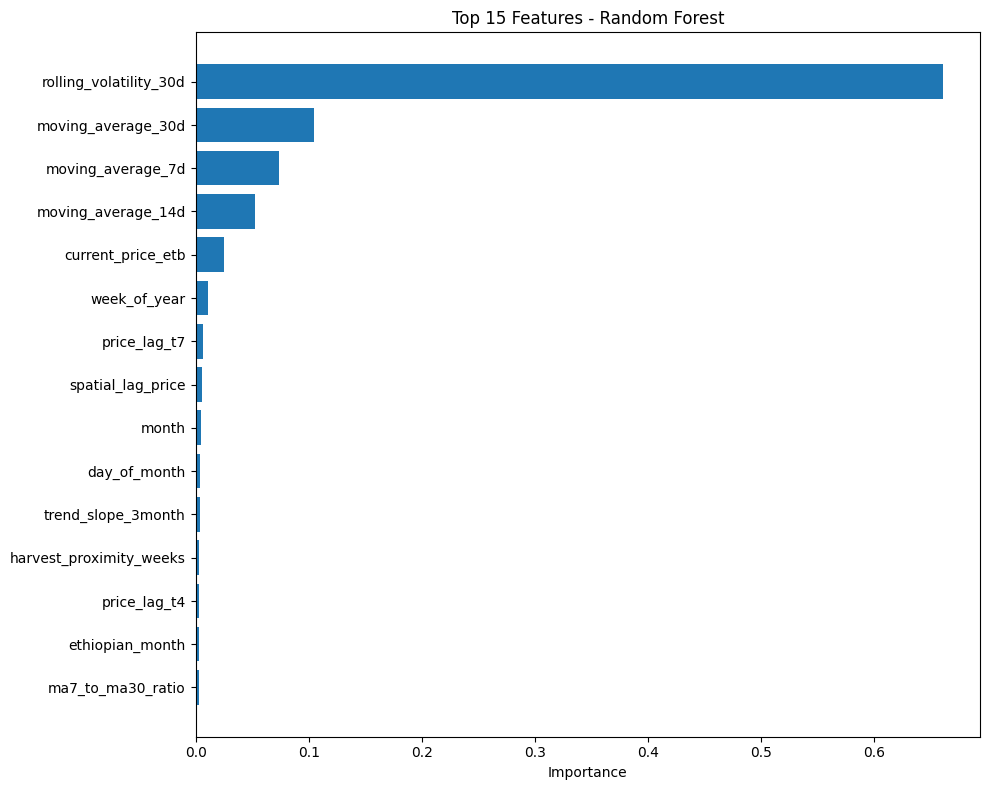


📊 STEP 10: Prediction visualization...


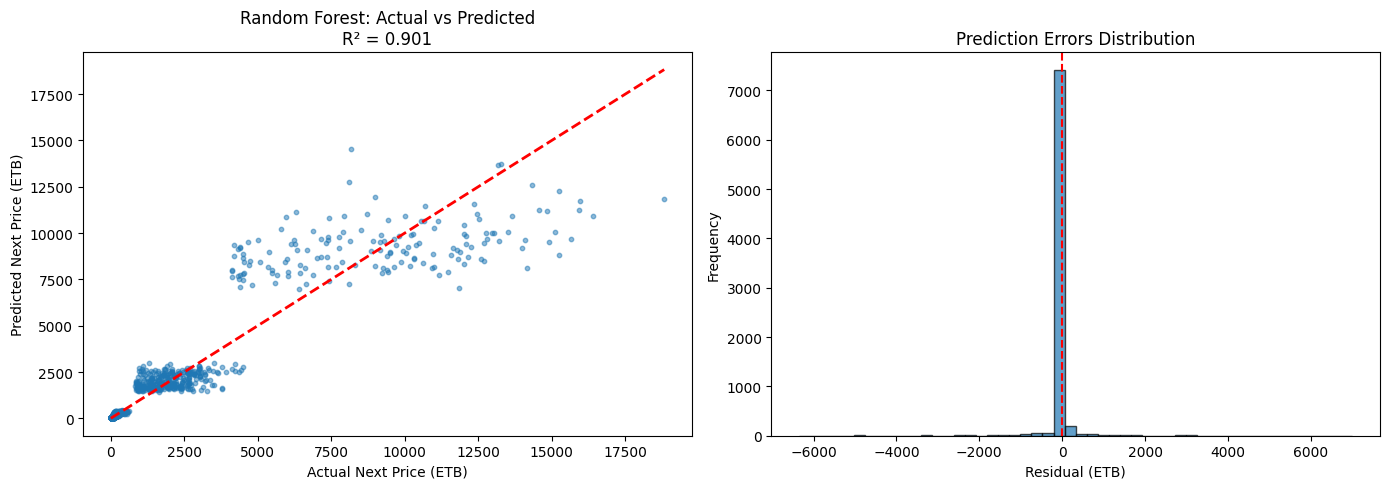


📈 Prediction Statistics:
   Mean Absolute Error: 86.18 ETB
   Median Absolute Error: 8.86 ETB
   Mean APE: 34.20%
   Median APE: 24.21%
   Predictions within 10%: 22.2%
   Predictions within 20%: 42.3%

💾 STEP 11: Saving model for production...
✅ Model saved to: /content/drive/MyDrive/market_price_model/
   Files: best_model.pkl, scaler.pkl, categorical_encoder.pkl, feature_cols.pkl

🚀 STEP 12: Creating prediction function...

📝 Testing prediction function...

🔮 Sample Prediction:
   Commodity: Barley (Food)
   Market: Adama (Nazret)
   Date: 2024-06-15
   Predicted Next Price: 32.75 ETB

✅ FINAL MODEL SUMMARY

📊 DATASET INFORMATION:
   Total records:      39,852
   Training set:       31,881 (80%)
   Test set:           7,971 (20%)

🎯 MODEL PERFORMANCE:
   Best Model:         Random Forest
   MAE:                86.18 ETB
   MAPE:               34.20%
   R² Score:           0.901

🔧 FEATURES:
   Total features:     38
   Feature types:      Numerical (33), Categorical (5)

💾 SAVED FI

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import OrdinalEncoder, RobustScaler

# ============================================================================
# STEP 1: BASIC SETUP
# ============================================================================

print("\n🔧 STEP 1: Initial setup...")

# Make a copy
df = df.copy()

# Required columns
required_cols = ["date", "current_price_etb", "commodity_item_type", "market_location"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Convert date
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).copy()

# Sort by entity and time
group_cols = ["commodity_item_type", "market_location"]
df = df.sort_values(group_cols + ["date"]).reset_index(drop=True)

print(f"✅ Date range: {df['date'].min()} to {df['date'].max()}")
print(f"✅ Initial dataset size: {len(df):,}")

# Remove exact duplicate entity-date rows
before_dupes = len(df)
df = df.drop_duplicates(subset=group_cols + ["date"], keep="first").copy()
after_dupes = len(df)
print(f"✅ Removed duplicate entity-date rows: {before_dupes - after_dupes:,}")
print(f"✅ Dataset size after deduplication: {len(df):,}")

# ============================================================================
# STEP 2: MISSING VALUES - SAFE HANDLING
# ============================================================================

print("\n🔧 STEP 2: Data cleaning and preprocessing...")

missing_before = df.isnull().sum()
missing_before_pct = (missing_before / len(df)) * 100
missing_df = pd.DataFrame({"Missing": missing_before, "Percentage": missing_before_pct})
print("\n📊 Missing values before cleaning:")
print(missing_df[missing_df["Missing"] > 0])

# Identify basic column types before feature engineering
base_categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
base_numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Group-wise forward fill only (no backfill leakage)
for col in base_categorical_cols:
    df[col] = df.groupby(group_cols)[col].transform(lambda s: s.ffill())

for col in base_numerical_cols:
    if col != "current_price_etb":
        df[col] = df.groupby(group_cols)[col].transform(lambda s: s.ffill())

print(f"✅ Remaining missing values after safe forward fill: {df.isnull().sum().sum()}")

# ============================================================================
# STEP 3: FEATURE ENGINEERING - PAST ONLY
# ============================================================================

print("\n🔧 STEP 3: Feature engineering...")

# Time features
df["month"] = df["date"].dt.month
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["date"].dt.dayofweek + 1
df["quarter"] = df["date"].dt.quarter
df["day_of_month"] = df["date"].dt.day
df["days_since_start"] = (df["date"] - df["date"].min()).dt.days
df["is_weekend"] = (df["day_of_week"] >= 6).astype(int)

# Safe historical price features per commodity-market group
g = df.groupby(group_cols)["current_price_etb"]

# Safe historical price features per commodity-market group
df["price_lag_t1"] = df.groupby(group_cols)["current_price_etb"].shift(1)
df["price_lag_t7"] = df.groupby(group_cols)["current_price_etb"].shift(7)

df["moving_average_7d"] = (
    df.groupby(group_cols)["current_price_etb"]
      .transform(lambda s: s.shift(1).rolling(7).mean())
)

df["moving_average_14d"] = (
    df.groupby(group_cols)["current_price_etb"]
      .transform(lambda s: s.shift(1).rolling(14).mean())
)

df["moving_average_30d"] = (
    df.groupby(group_cols)["current_price_etb"]
      .transform(lambda s: s.shift(1).rolling(30).mean())
)

df["rolling_volatility_30d"] = (
    df.groupby(group_cols)["current_price_etb"]
      .transform(lambda s: s.shift(1).rolling(30).std())
)

df["price_change_rate_percent"] = (
    df.groupby(group_cols)["current_price_etb"]
      .transform(lambda s: s.pct_change().shift(1) * 100)
)

df["price_acceleration"] = (
    df.groupby(group_cols)["price_change_rate_percent"]
      .transform(lambda s: s.diff())
)

df["price_to_ma7_ratio"] = df["price_lag_t1"] / (df["moving_average_7d"] + 1e-6)
df["price_to_ma30_ratio"] = df["price_lag_t1"] / (df["moving_average_30d"] + 1e-6)
df["ma7_to_ma30_ratio"] = df["moving_average_7d"] / (df["moving_average_30d"] + 1e-6)

# FUTURE TARGET: next-period price
df["target_price_etb"] = df.groupby(group_cols)["current_price_etb"].shift(-1)

print("✅ Feature engineering complete")

# ============================================================================
# STEP 4: DROP ROWS UNSUITABLE FOR FORECASTING
# ============================================================================

print("\n⚙️ STEP 4: Preparing data for modeling...")

# Drop rows where target is unavailable
df = df.dropna(subset=["target_price_etb"]).copy()

# Drop early rows that do not yet have lag/rolling history
feature_nan_cols = [
    "price_lag_t1", "moving_average_7d", "moving_average_30d",
    "price_change_rate_percent", "price_to_ma30_ratio"
]
existing_feature_nan_cols = [c for c in feature_nan_cols if c in df.columns]
df = df.dropna(subset=existing_feature_nan_cols).copy()

# Fill remaining numeric gaps conservatively
post_num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in post_num_cols:
    if col not in ["target_price_etb"]:
        df[col] = df.groupby(group_cols)[col].transform(lambda s: s.ffill())

# Final fallback for non-target columns only
for col in df.columns:
    if col != "target_price_etb":
        if df[col].dtype.kind in "biufc":
            df[col] = df[col].fillna(df[col].median())
        else:
            mode_vals = df[col].mode(dropna=True)
            df[col] = df[col].fillna(mode_vals.iloc[0] if len(mode_vals) > 0 else "unknown")

print(f"✅ Final dataset size: {len(df):,} records")

# ============================================================================
# STEP 5: FEATURE SELECTION
# ============================================================================

target = "target_price_etb"

exclude_cols = [
    "date",
    "target_price_etb"
]

# Keep commodity and market as features
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in exclude_cols]

numerical_cols = [
    c for c in df.columns
    if c not in exclude_cols + categorical_cols
]

feature_cols = numerical_cols + categorical_cols

print("\n📊 Feature summary:")
print(f"   Total features: {len(feature_cols)}")
print(f"   Numerical: {len(numerical_cols)}")
print(f"   Categorical: {len(categorical_cols)}")

# Prepare X and y
X = df[feature_cols].copy()
y = df[target].copy()

# ============================================================================
# STEP 6: TIME-BASED TRAIN-TEST SPLIT
# ============================================================================

print("\n📅 STEP 5: Train-test split...")

df_sorted = df.sort_values("date").copy()
X_sorted = X.loc[df_sorted.index].copy()
y_sorted = y.loc[df_sorted.index].copy()

test_size = 0.2
split_idx = int(len(df_sorted) * (1 - test_size))

X_train = X_sorted.iloc[:split_idx].copy()
X_test = X_sorted.iloc[split_idx:].copy()
y_train = y_sorted.iloc[:split_idx].copy()
y_test = y_sorted.iloc[split_idx:].copy()

train_dates = df_sorted["date"].iloc[:split_idx]
test_dates = df_sorted["date"].iloc[split_idx:]

print(f"✅ Training set: {len(X_train):,} records")
print(f"✅ Test set: {len(X_test):,} records")
print(f"✅ Train period: {train_dates.min()} to {train_dates.max()}")
print(f"✅ Test period:  {test_dates.min()} to {test_dates.max()}")

# ============================================================================
# STEP 7: FIT PREPROCESSING ON TRAIN ONLY
# ============================================================================

print("\n🔧 STEP 6: Train-only preprocessing...")

# Encode categorical features
encoder = None
if len(categorical_cols) > 0:
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols].astype(str))
    X_test[categorical_cols] = encoder.transform(X_test[categorical_cols].astype(str))

# Scale numerical features
scaler = RobustScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Final NaN check
print(f"✅ Final check - X_train NaN: {X_train.isnull().sum().sum()}, X_test NaN: {X_test.isnull().sum().sum()}")
print(f"✅ y_train NaN: {y_train.isnull().sum()}, y_test NaN: {y_test.isnull().sum()}")

if X_train.isnull().sum().sum() > 0:
    X_train = X_train.fillna(0)
if X_test.isnull().sum().sum() > 0:
    X_test = X_test.fillna(0)

# ============================================================================
# STEP 8: TRAIN MODELS
# ============================================================================

print("\n🤖 STEP 7: Training multiple models...")

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "Ridge": Ridge(alpha=1.0)
}

trained_models = {}
print("\nTraining models...")

for name, model in models.items():
    print(f"   Training {name}...")
    try:
        model.fit(X_train, y_train)
        trained_models[name] = model
        print(f"   ✅ {name} trained successfully")
    except Exception as e:
        print(f"   ❌ Error training {name}: {e}")

# ============================================================================
# STEP 9: EVALUATION
# ============================================================================

print("\n📈 STEP 8: Model evaluation...")

results = []
best_model = None
best_name = None
best_mape = float("inf")

print("\n" + "=" * 100)
print(f"{'Model':<20} {'MAE (ETB)':<12} {'RMSE (ETB)':<12} {'MAPE (%)':<10} {'R² Score':<10}")
print("=" * 100)

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R²": r2
    })

    print(f"{name:<20} {mae:<12.2f} {rmse:<12.2f} {mape:<10.2f} {r2:<10.3f}")

    if mape < best_mape:
        best_mape = mape
        best_model = model
        best_name = name

print("=" * 100)
print(f"\n✅ BEST MODEL: {best_name} (MAPE: {best_mape:.2f}%)")

best_result = next(r for r in results if r["Model"] == best_name)

# ============================================================================
# STEP 10: FEATURE IMPORTANCE
# ============================================================================

feature_importance = None

if best_name == "Random Forest":
    print("\n🎯 STEP 9: Feature importance analysis...")

    importance = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": importance
    }).sort_values("importance", ascending=False)

    print("\n   Top 15 Most Important Features:")
    print("   " + "-" * 70)
    for rank, (_, row) in enumerate(feature_importance.head(15).iterrows(), start=1):
        bar = "█" * int(row["importance"] * 50)
        print(f"   {rank:2} | {row['feature'][:35]:35} | {row['importance']*100:5.1f}% {bar}")

    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance.head(15)["feature"][::-1], feature_importance.head(15)["importance"][::-1])
    plt.xlabel("Importance")
    plt.title(f"Top 15 Features - {best_name}")
    plt.tight_layout()
    plt.show()

# ============================================================================
# STEP 11: PREDICTION VISUALIZATION
# ============================================================================

print("\n📊 STEP 10: Prediction visualization...")

y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual Next Price (ETB)")
axes[0].set_ylabel("Predicted Next Price (ETB)")
axes[0].set_title(f"{best_name}: Actual vs Predicted\nR² = {r2_score(y_test, y_pred_best):.3f}")

axes[1].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Residual (ETB)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Prediction Errors Distribution")
axes[1].axvline(x=0, color="r", linestyle="--")

plt.tight_layout()
plt.show()

safe_denominator = np.where(np.abs(y_test) < 1e-6, np.nan, y_test)
ape = np.abs(residuals / safe_denominator) * 100

print("\n📈 Prediction Statistics:")
print(f"   Mean Absolute Error: {np.mean(np.abs(residuals)):.2f} ETB")
print(f"   Median Absolute Error: {np.median(np.abs(residuals)):.2f} ETB")
print(f"   Mean APE: {np.nanmean(ape):.2f}%")
print(f"   Median APE: {np.nanmedian(ape):.2f}%")
print(f"   Predictions within 10%: {(ape <= 10).mean()*100:.1f}%")
print(f"   Predictions within 20%: {(ape <= 20).mean()*100:.1f}%")

# ============================================================================
# STEP 12: SAVE MODEL ARTIFACTS
# ============================================================================

print("\n💾 STEP 11: Saving model for production...")

save_path = "/content/drive/MyDrive/market_price_model/"
os.makedirs(save_path, exist_ok=True)

joblib.dump(best_model, f"{save_path}best_model.pkl")
joblib.dump(scaler, f"{save_path}scaler.pkl")
joblib.dump(encoder, f"{save_path}categorical_encoder.pkl")
joblib.dump(feature_cols, f"{save_path}feature_cols.pkl")
joblib.dump(numerical_cols, f"{save_path}numerical_cols.pkl")
joblib.dump(categorical_cols, f"{save_path}categorical_cols.pkl")
joblib.dump(group_cols, f"{save_path}group_cols.pkl")

print(f"✅ Model saved to: {save_path}")
print("   Files: best_model.pkl, scaler.pkl, categorical_encoder.pkl, feature_cols.pkl")

# ============================================================================
# STEP 13: PREDICTION FUNCTION
# ============================================================================

print("\n🚀 STEP 12: Creating prediction function...")

def make_features_from_history(history_df, weather_data, market_data, predict_date, commodity, market):
    """
    Build one-row feature input from historical series and external inputs.
    history_df should contain past rows for the same commodity-market pair.
    """
    history_df = history_df.copy()
    history_df["date"] = pd.to_datetime(history_df["date"])
    history_df = history_df.sort_values("date")

    if len(history_df) == 0:
        raise ValueError("history_df is empty for this commodity-market pair")

    last_price = history_df["current_price_etb"].iloc[-1]
    last_7 = history_df["current_price_etb"].tail(7)
    last_14 = history_df["current_price_etb"].tail(14)
    last_30 = history_df["current_price_etb"].tail(30)

    ma7 = last_7.mean() if len(last_7) > 0 else np.nan
    ma14 = last_14.mean() if len(last_14) > 0 else np.nan
    ma30 = last_30.mean() if len(last_30) > 0 else np.nan
    vol30 = last_30.std() if len(last_30) > 1 else 0

    pct_changes = history_df["current_price_etb"].pct_change() * 100
    last_change = pct_changes.iloc[-1] if len(pct_changes.dropna()) > 0 else 0
    prev_change = pct_changes.iloc[-2] if len(pct_changes.dropna()) > 1 else 0
    acceleration = last_change - prev_change

    row = {
        "commodity_item_type": commodity,
        "market_location": market,
        "month": predict_date.month,
        "week_of_year": int(predict_date.isocalendar()[1]),
        "day_of_week": predict_date.weekday() + 1,
        "quarter": (predict_date.month - 1) // 3 + 1,
        "day_of_month": predict_date.day,
        "days_since_start": (predict_date - df["date"].min()).days,
        "is_weekend": 1 if predict_date.weekday() >= 5 else 0,
        "price_lag_t1": last_price,
        "price_lag_t7": history_df["current_price_etb"].iloc[-7] if len(history_df) >= 7 else last_price,
        "moving_average_7d": ma7 if not pd.isna(ma7) else last_price,
        "moving_average_14d": ma14 if not pd.isna(ma14) else last_price,
        "moving_average_30d": ma30 if not pd.isna(ma30) else last_price,
        "rolling_volatility_30d": vol30,
        "price_change_rate_percent": last_change if not pd.isna(last_change) else 0,
        "price_acceleration": acceleration if not pd.isna(acceleration) else 0,
        "price_to_ma7_ratio": last_price / ((ma7 if not pd.isna(ma7) else last_price) + 1e-6),
        "price_to_ma30_ratio": last_price / ((ma30 if not pd.isna(ma30) else last_price) + 1e-6),
        "ma7_to_ma30_ratio": ((ma7 if not pd.isna(ma7) else last_price) / ((ma30 if not pd.isna(ma30) else last_price) + 1e-6)),
        "rainfall_anomaly_mm": weather_data.get("rainfall_anomaly_mm", 0),
        "temperature_mean_c": weather_data.get("temperature_mean_c", 22),
        "temperature_max_c": weather_data.get("temperature_max_c", 26),
        "temperature_min_c": weather_data.get("temperature_min_c", 18),
        "supply_inflow_units": market_data.get("supply_inflow_units", 500),
        "demand_proxy_queries": market_data.get("demand_proxy_queries", 600),
    }

    if "high_low_spread" in feature_cols:
        row["high_low_spread"] = row["temperature_max_c"] - row["temperature_min_c"]

    if "rainfall_temp_interaction" in feature_cols:
        row["rainfall_temp_interaction"] = row["rainfall_anomaly_mm"] * row["temperature_mean_c"]

    if "price_volatility_flag" in feature_cols:
        row["price_volatility_flag"] = int(row["rolling_volatility_30d"] > 0)

    if "supply_demand_gap" in feature_cols:
        row["supply_demand_gap"] = row["supply_inflow_units"] - row["demand_proxy_queries"]

    input_df = pd.DataFrame([row])

    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_cols].copy()

    if len(categorical_cols) > 0:
        input_df[categorical_cols] = encoder.transform(input_df[categorical_cols].astype(str))

    input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])

    return input_df

def predict_next_price(history_df, commodity, market, predict_date, weather_data=None, market_data=None):
    if weather_data is None:
        weather_data = {}
    if market_data is None:
        market_data = {}

    features = make_features_from_history(
        history_df=history_df,
        weather_data=weather_data,
        market_data=market_data,
        predict_date=predict_date,
        commodity=commodity,
        market=market
    )
    prediction = best_model.predict(features)[0]
    return prediction

# Sample test
print("\n📝 Testing prediction function...")

sample_commodity = df["commodity_item_type"].iloc[0]
sample_market = df["market_location"].iloc[0]

sample_history = df[
    (df["commodity_item_type"] == sample_commodity) &
    (df["market_location"] == sample_market)
].copy()

test_date = datetime(2024, 6, 15)
test_weather = {"rainfall_anomaly_mm": 25, "temperature_mean_c": 22, "temperature_max_c": 26, "temperature_min_c": 18}
test_market = {"supply_inflow_units": 450, "demand_proxy_queries": 600}

predicted = predict_next_price(
    history_df=sample_history[sample_history["date"] < pd.Timestamp(test_date)],
    commodity=sample_commodity,
    market=sample_market,
    predict_date=test_date,
    weather_data=test_weather,
    market_data=test_market
)

print("\n🔮 Sample Prediction:")
print(f"   Commodity: {sample_commodity}")
print(f"   Market: {sample_market}")
print(f"   Date: {test_date.strftime('%Y-%m-%d')}")
print(f"   Predicted Next Price: {predicted:.2f} ETB")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("✅ FINAL MODEL SUMMARY")
print("=" * 80)

print(f"""
📊 DATASET INFORMATION:
   Total records:      {len(df):,}
   Training set:       {len(X_train):,} ({100*(1-test_size):.0f}%)
   Test set:           {len(X_test):,} ({test_size*100:.0f}%)

🎯 MODEL PERFORMANCE:
   Best Model:         {best_name}
   MAE:                {best_result['MAE']:.2f} ETB
   MAPE:               {best_result['MAPE']:.2f}%
   R² Score:           {best_result['R²']:.3f}

🔧 FEATURES:
   Total features:     {len(feature_cols)}
   Feature types:      Numerical ({len(numerical_cols)}), Categorical ({len(categorical_cols)})

💾 SAVED FILES:
   Location:           {save_path}

🚀 MODEL IS READY FOR LEAKAGE-SAFE FORECASTING!
""")

print("\n🎉 Market Price Forecasting Model Successfully Trained!")